# 03 · Matching and difference-in-differences: how much loss did the highway cause?

**Mirrors scripts:** `python/04_matching_did.py` and `python/10_results_charts.py`.
**Inputs:** `data/tables/segment_zone_panel_DS2020_2026.csv`, `results/seg_cov.csv` (notebook 01).
**Outputs:** `results/matching_balance.csv`, `matched_pairs.csv`, `did_results.csv`, `event_study.csv`, `seg_cov_w.csv`, `Figure6_loss_trajectories.png`, `Figure7_event_study.png`.

### The logic in one table

| | Before construction (DS2021–DS2024) | After (DS2025–DS2026) | Change |
|---|---|---|---|
| Section 1 | A | B | B − A |
| Matched controls | C | D | D − C |
| **Effect of the road** | | | **(B − A) − (D − C)** |

The controls' change (D − C) estimates what would have happened in Section 1 without the road: urban growth, climate, classification noise between years. Subtracting it leaves the part caused by construction. This holds if, **without the road, Section 1 would have followed the same trend as its controls** (the *parallel-trends* assumption). The **event study** checks that assumption by looking at the years *before* construction.

In [1]:
# --- Setup: find the repository folders (works from notebooks/ or the repo root) ---
import sys, warnings
from pathlib import Path
ROOT = Path.cwd().resolve()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / 'python'))
from paths import DATA, VEC, RAS, TAB, VAL, RES, ZONES, CRS   # shared folder locations
warnings.filterwarnings('ignore')

import numpy as np, pandas as pd
import matplotlib.pyplot as plt
pd.set_option('display.width', 160); pd.set_option('display.max_columns', 30)
plt.rcParams.update({'figure.dpi': 110, 'axes.spines.top': False, 'axes.spines.right': False})
print('Repository root found:', ROOT.name)

Repository root found: lagos-calabar-s1-vegetation-loss


In [2]:
import statsmodels.api as sm
rng = np.random.default_rng(1)                   # fixed seed: bootstrap results are reproducible
d = pd.read_csv(TAB / 'segment_zone_panel_DS2020_2026.csv')
b = pd.read_csv(RES / 'seg_cov.csv')
print(d.shape, b.shape)

(4396, 17) (157, 17)


## 1. Matching

Section 1 was far more urbanised than the controls in 2020 (notebook 01). For each Section 1 segment we therefore find the **two most similar control segments** in 2020 vegetation and built-up share.

* **Distance:** Mahalanobis, $\;d(t,c) = \sqrt{(x_t - x_c)^\top \Sigma^{-1} (x_t - x_c)}$, where $\Sigma$ is the covariance of the two shares across all 157 segments. It accounts for the fact that vegetation and built-up shares are strongly (negatively) correlated.
* **k = 2 with replacement:** a control can serve several Section 1 segments.
* **Caliper 0.5:** a Section 1 segment is kept only if both its matches are closer than 0.5. Segments with no similar control (the most urbanised western ones) are dropped: this is *common support*.
* **Weights:** each kept Section 1 segment weighs 1; each control weighs 1/2 for every time it is used.

In [3]:
X = ['veg', 'built']
T = b[b.treated == 1].reset_index(drop=True); C = b[b.treated == 0].reset_index(drop=True)
Si = np.linalg.inv(np.cov(b[X].values.T))
D = np.array([[np.sqrt((t - c) @ Si @ (t - c)) for c in C[X].values] for t in T[X].values])
K, CAL = 2, 0.5
idx = np.argsort(D, axis=1)[:, :K]; dm = np.take_along_axis(D, idx, 1); keep = dm.max(1) <= CAL

w, pairs = {}, []
for i in range(len(T)):
    if keep[i]:
        w[T.seg_id[i]] = 1.0
        for j, dist in zip(idx[i], dm[i]):
            w[C.seg_id[j]] = w.get(C.seg_id[j], 0) + 1 / K
            pairs.append((T.seg_id[i], C.seg_id[j], round(dist, 3)))
    else:
        pairs.append((T.seg_id[i], '(no match within caliper)', round(dm[i].min(), 3)))
b['match_w'] = b.seg_id.map(w).fillna(0)
pairs = pd.DataFrame(pairs, columns=['treated_segment', 'matched_control', 'mahalanobis_distance'])
pairs.to_csv(RES / 'matched_pairs.csv', index=False)
b.to_csv(RES / 'seg_cov_w.csv', index=False)
print(f'Section 1 segments matched: {keep.sum()} of {len(T)}; distinct controls used: {(b[b.treated == 0].match_w > 0).sum()}')
pairs.head(8)

Section 1 segments matched: 22 of 47; distinct controls used: 21


,treated_segment,matched_control,mahalanobis_distance
0,T01,(no match within caliper),1.479
1,T02,(no match within caliper),0.833
2,T03,(no match within caliper),1.046
3,T04,(no match within caliper),0.813
4,T05,(no match within caliper),0.977
5,T06,(no match within caliper),0.900
6,T07,(no match within caliper),1.291
7,T08,(no match within caliper),1.314


### Balance before and after matching

In [4]:
tr = b[(b.treated == 1) & (b.match_w > 0)]; co = b[(b.treated == 0) & (b.match_w > 0)]
bal = []
for v, lab in [('veg', 'Vegetation share 2020'), ('built', 'Built-up share 2020'), ('bare', 'Bare/sand share 2020'),
               ('waterfrac', 'Water share of cell'), ('elev', 'Mean elevation (m)'), ('dcbd_km', 'Distance to Lagos Island CBD (km)')]:
    sd = np.sqrt((T[v].var() + C[v].var()) / 2)
    bal.append(dict(covariate=lab, used_in_matching='Yes' if v in X else 'No',
                    S1_mean_all=T[v].mean(), Ctrl_mean_all=C[v].mean(), SMD_before=(T[v].mean() - C[v].mean()) / sd,
                    S1_mean_matched=tr[v].mean(), Ctrl_mean_matched=np.average(co[v], weights=co.match_w),
                    SMD_after=(tr[v].mean() - np.average(co[v], weights=co.match_w)) / sd))
bal = pd.DataFrame(bal); bal.to_csv(RES / 'matching_balance.csv', index=False)
bal.round(2)

,covariate,used_in_matching,S1_mean_all,Ctrl_mean_all,SMD_before,S1_mean_matched,Ctrl_mean_matched,SMD_after
0,Vegetation share 2020,Yes,0.40,0.67,-1.36,0.61,0.62,-0.03
1,Built-up share 2020,Yes,0.49,0.13,1.91,0.30,0.28,0.06
2,Bare/sand share 2020,No,0.11,0.20,-1.06,0.09,0.10,-0.06
3,Water share of cell,No,0.48,0.51,-0.23,0.48,0.54,-0.59
4,Mean elevation (m),No,3.88,3.36,0.39,4.68,2.89,1.33
5,Distance to Lagos Island CBD (km),No,27.79,64.03,-1.52,38.97,33.45,0.23


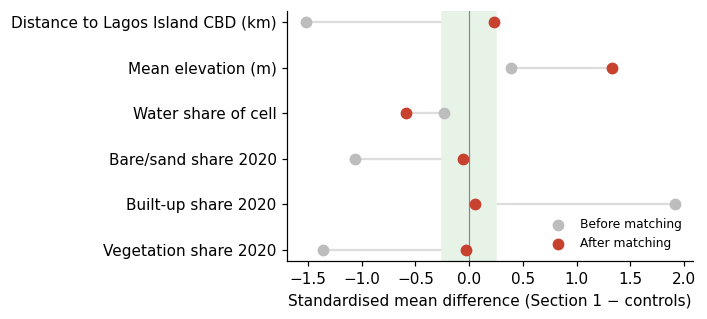

In [5]:
fig, ax = plt.subplots(figsize=(6.5, 3))
y = np.arange(len(bal))
ax.scatter(bal.SMD_before, y, color='#BDBDBD', s=45, label='Before matching', zorder=3)
ax.scatter(bal.SMD_after, y, color='#C8412F', s=45, label='After matching', zorder=3)
for yi, a, c in zip(y, bal.SMD_before, bal.SMD_after):
    ax.plot([a, c], [yi, yi], color='#DDDDDD', zorder=1)
ax.axvspan(-0.25, 0.25, color='#E8F3E8'); ax.axvline(0, color='#888', lw=0.8)
ax.set_yticks(y); ax.set_yticklabels(bal.covariate); ax.set_xlabel('Standardised mean difference (Section 1 − controls)')
ax.legend(frameon=False, fontsize=8, loc='lower right'); plt.tight_layout(); plt.show()

Matching removes the large urbanisation gap (vegetation SMD −1.36 → −0.03; built-up +1.91 → +0.06). Water share and elevation stay imbalanced, so specification **C** below adds them as controls. The matched Section 1 segments are the less urbanised, eastern part of the corridor; the estimates describe that part.

## 2. The outcome and the regression models

$Y_{it}$ = % of unit *i*'s DS2020 vegetation that is not vegetated in year *t* (units with ≥ 1 ha of DS2020 vegetation). Each zone (F, B1, B2, B3) is analysed separately.

**Event study** (reference year DS2024, the last before construction):
$$Y_{it} = \alpha_i + \lambda_t + \sum_{k \ne 2024} \beta_k \,(T_i \times \mathbb 1[t=k]) + \varepsilon_{it}$$

**Pooled difference-in-differences** (DS2021–DS2026; DS2020 is 0 by construction):
$$Y_{it} = \alpha_i + \lambda_t + \delta\,(T_i \times Post_t) + \varepsilon_{it}, \qquad Post_t = 1 \text{ for DS2025, DS2026}$$

$\alpha_i$ = unit fixed effects (each unit's own level), $\lambda_t$ = year fixed effects (shocks common to all units in a year), $T_i$ = 1 for Section 1. **δ is the extra percentage-point loss in Section 1 after construction.**

Three specifications:

| | Sample | Adjustment |
|---|---|---|
| **A** | all units | none |
| **B (main)** | matched units, weighted | matching |
| **C** | all units | baseline vegetation, built-up and elevation × year dummies |

Standard errors are **clustered by 1 km segment** (the four zones and seven years of a segment are not independent). With only about 20 clusters per group, the matched specification also gets a **wild cluster bootstrap** p-value (Rademacher weights, null imposed, 499 draws; Cameron et al., 2008).

In [6]:
d = d[d.a_veg2020 >= 1e4].copy(); d['y'] = 100 * d.a_veglost / d.a_veg2020
d = d.merge(b[['seg_id', 'veg', 'built', 'elev', 'match_w']], on='seg_id')

def fit(s, terms, wcol=None, extra=None):
    s = s.reset_index(drop=True)
    M = pd.concat([s[terms].astype(float), pd.get_dummies(s.unit_id, dtype=float),
                   pd.get_dummies(s.year, prefix='yr', drop_first=True, dtype=float)] + ([extra(s)] if extra else []), axis=1)
    W = s[wcol].values if wcol else None
    mod = (sm.WLS(s.y, M, weights=W) if wcol else sm.OLS(s.y, M)).fit(
        cov_type='cluster', cov_kwds={'groups': pd.factorize(s.seg_id)[0]})
    return mod, M, W

def cov_trends(s):   # baseline covariates x year dummies (specification C)
    return pd.DataFrame({f'{v}_x{yr}': (s.year == yr) * s[v] for yr in sorted(s.year.unique())[1:] for v in ['veg', 'built', 'elev']})

def wild(s, M, W, term, B=499):
    """Wild cluster bootstrap p-value (Rademacher weights, null imposed)."""
    s = s.reset_index(drop=True); cl = pd.factorize(s.seg_id)[0]; G = cl.max() + 1
    Mr = M.drop(columns=[term]); w = np.ones(len(s)) if W is None else W; sw = np.sqrt(w)
    br = np.linalg.lstsq(Mr.values * sw[:, None], s.y.values * sw, rcond=None)[0]
    fr = Mr.values @ br; er = s.y.values - fr
    tstat = lambda y: sm.WLS(y, M, weights=w).fit(cov_type='cluster', cov_kwds={'groups': cl}).tvalues[term]
    t0 = tstat(s.y.values)
    cnt = sum(abs(tstat(fr + er * rng.choice([-1, 1], G)[cl])) >= abs(t0) for _ in range(B))
    return (cnt + 1) / (B + 1)

## 3. Estimate everything

(The wild bootstrap takes a few seconds per zone.)

In [7]:
rows, es = [], []
EV = [2021, 2022, 2023, 2025, 2026]
for z, zl in ZONES:
    for spec in ['A: Unmatched (all segments)', 'B: Matched (common support)', 'C: All segments + baseline covariate trends']:
        s = d[d.zone == z].copy(); wcol = extra = None
        if spec.startswith('B'): s = s[s.match_w > 0]; wcol = 'match_w'
        if spec.startswith('C'): extra = cov_trends
        # pooled DiD
        s2 = s[s.year >= 2021].copy(); s2['post'] = ((s2.year >= 2025) & (s2.treated == 1)).astype(int)
        m, M, W = fit(s2, ['post'], wcol, extra)
        ci = m.conf_int().loc['post']
        rows.append(dict(zone=z, distance=zl, spec=spec, estimate=m.params.post, ci_low=ci[0], ci_high=ci[1],
                         p_cluster=m.pvalues.post, p_wild_bootstrap=wild(s2, M, W, 'post') if spec[0] == 'B' else np.nan,
                         treated_units=s[s.treated == 1].unit_id.nunique(), control_units=s[s.treated == 0].unit_id.nunique()))
        # event study
        for k in EV: s[f'e{k}'] = ((s.year == k) & (s.treated == 1)).astype(int)
        me, _, _ = fit(s, [f'e{k}' for k in EV], wcol, extra)
        for k in [2021, 2022, 2023, 2024, 2025, 2026]:
            if k == 2024:
                es.append(dict(zone=z, spec=spec, year=k, estimate=0, ci_low=0, ci_high=0))
            else:
                c = me.conf_int().loc[f'e{k}']
                es.append(dict(zone=z, spec=spec, year=k, estimate=me.params[f'e{k}'], ci_low=c[0], ci_high=c[1]))
res = pd.DataFrame(rows); es = pd.DataFrame(es)
res.to_csv(RES / 'did_results.csv', index=False); es.to_csv(RES / 'event_study.csv', index=False)
res.round(3)

,zone,distance,spec,estimate,ci_low,ci_high,p_cluster,p_wild_bootstrap,treated_units,control_units
0,F,Footprint,A: Unmatched (all segments),62.503,53.753,71.253,0.000,NaN,34,85
1,F,Footprint,B: Matched (common support),64.398,50.526,78.270,0.000,0.002,21,13
2,F,Footprint,C: All segments + baseline covariate trends,63.560,43.352,83.768,0.000,NaN,34,85
3,B1,0–500 m,A: Unmatched (all segments),11.695,8.010,15.379,0.000,NaN,42,110
4,B1,0–500 m,B: Matched (common support),6.547,2.358,10.737,0.002,0.004,22,21
5,B1,0–500 m,C: All segments + baseline covariate trends,8.956,4.259,13.653,0.000,NaN,42,110
6,B2,500 m–1 km,A: Unmatched (all segments),6.226,3.159,9.292,0.000,NaN,42,109
7,B2,500 m–1 km,B: Matched (common support),3.027,-0.397,6.452,0.083,0.068,22,20
8,B2,500 m–1 km,C: All segments + baseline covariate trends,0.581,-3.953,5.114,0.802,NaN,42,109
9,B3,1–5 km,A: Unmatched (all segments),6.930,5.208,8.653,0.000,NaN,47,110


### Main result (specification B, matched)

In [8]:
main = res[res.spec.str.startswith('B')].copy()
main['95% CI'] = main.apply(lambda r: f'{r.ci_low:.1f} to {r.ci_high:.1f}', axis=1)
main[['distance', 'estimate', '95% CI', 'p_cluster', 'p_wild_bootstrap', 'treated_units', 'control_units']].round(3)

,distance,estimate,95% CI,p_cluster,p_wild_bootstrap,treated_units,control_units
1,Footprint,64.398,50.5 to 78.3,0.000,0.002,21,13
4,0–500 m,6.547,2.4 to 10.7,0.002,0.004,22,21
7,500 m–1 km,3.027,-0.4 to 6.5,0.083,0.068,22,20
10,1–5 km,1.046,-2.0 to 4.1,0.505,0.480,22,21


## 4. Event study: checking the years before construction

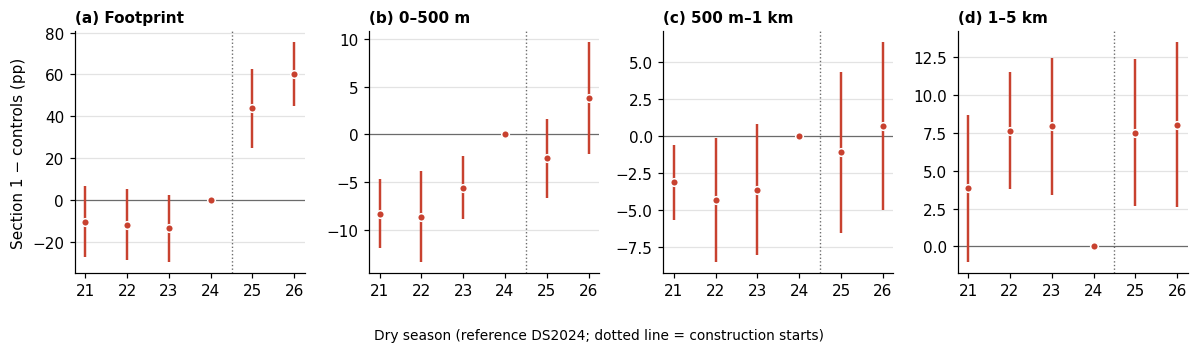

zone,F,B1,B2,B3
year,,,,
2021,-10.4,-8.3,-3.1,3.8
2022,-11.8,-8.6,-4.3,7.6
2023,-13.6,-5.6,-3.6,7.9
2024,0.0,0.0,0.0,0.0
2025,43.8,-2.5,-1.1,7.5
2026,60.3,3.8,0.7,8.1


In [9]:
S1C, INK, MUTED, GRID = '#C8412F', '#222222', '#6B6B6B', '#E3E3E3'
eb = es[es.spec.str.startswith('B')]
fig, axs = plt.subplots(1, 4, figsize=(11, 3.2), sharex=True)
for ax, (z, zl), lab in zip(axs, ZONES, 'abcd'):
    s = eb[eb.zone == z].sort_values('year')
    ax.axhline(0, color=MUTED, lw=0.8); ax.axvline(2024.5, color=MUTED, lw=0.9, ls=':')
    ax.vlines(s.year, s.ci_low, s.ci_high, color=S1C, lw=1.6)
    ax.plot(s.year, s.estimate, 'o', color=S1C, ms=5, mec='white', mew=1)
    ax.set_title(f'({lab}) {zl}', loc='left', fontweight='bold', fontsize=10)
    ax.set_xticks(range(2021, 2027)); ax.set_xticklabels(['21', '22', '23', '24', '25', '26']); ax.grid(axis='y', color=GRID)
axs[0].set_ylabel('Section 1 − controls (pp)')
fig.supxlabel('Dry season (reference DS2024; dotted line = construction starts)', fontsize=9)
plt.tight_layout(); plt.show()
eb.pivot(index='year', columns='zone', values='estimate')[['F', 'B1', 'B2', 'B3']].round(1)

**How to read it.** Points left of the dotted line should sit near zero if Section 1 and its controls were on the same path before construction.

* **Footprint:** flat and not significant before 2024, then +44 pp in DS2025 and +60 pp in DS2026. This is a clean, sharp construction effect.
* **0–500 m:** the pre-construction points are clearly **below zero** (about −9 to −6 pp): relative to DS2024, Section 1 was still catching up with the controls, so this band already had a **pre-trend**. After construction the estimates are −2.5 and +3.8 pp, neither significant. The pooled +6.5 pp therefore partly reflects that pre-existing trend.
* **500 m–1 km and 1–5 km:** no clear break at construction.

## 5. Cumulative loss trajectories (Figure 6)

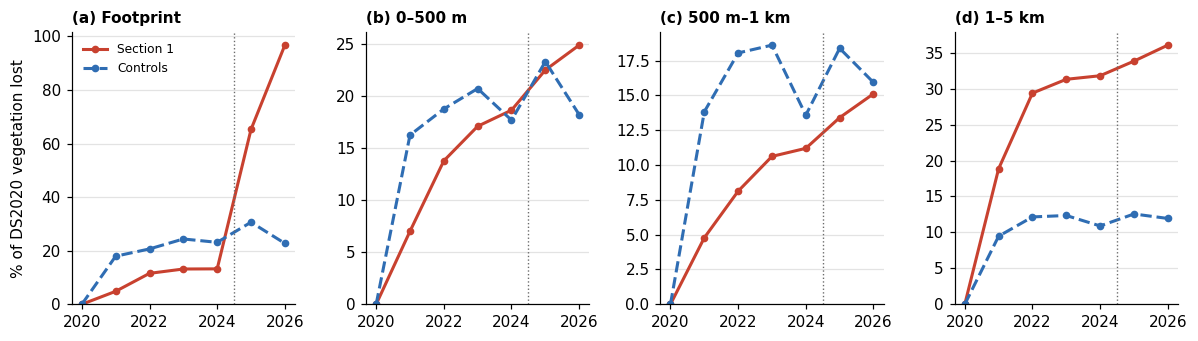

In [10]:
p = pd.read_csv(TAB / 'segment_zone_panel_DS2020_2026.csv'); p = p[p.a_veg2020 >= 1e4]
g = p.groupby(['zone', 'treated', 'year'])[['a_veglost', 'a_veg2020']].sum()
g = (100 * g.a_veglost / g.a_veg2020).rename('pct').reset_index()
fig, axs = plt.subplots(1, 4, figsize=(11, 3.2), sharex=True)
for ax, (z, zl), lab in zip(axs, ZONES, 'abcd'):
    for t, col, name, ls in [(1, S1C, 'Section 1', '-'), (0, '#2F6DB3', 'Controls', '--')]:
        s = g[(g.zone == z) & (g.treated == t)].sort_values('year')
        ax.plot(s.year, s.pct, color=col, lw=2, ls=ls, marker='o', ms=4, label=name)
    ax.axvline(2024.5, color=MUTED, lw=0.9, ls=':'); ax.set_ylim(bottom=0); ax.grid(axis='y', color=GRID)
    ax.set_title(f'({lab}) {zl}', loc='left', fontweight='bold', fontsize=10); ax.set_xticks([2020, 2022, 2024, 2026])
axs[0].set_ylabel('% of DS2020 vegetation lost'); axs[0].legend(frameon=False, fontsize=8)
plt.tight_layout(); plt.show()

The publication versions of both charts (300 dpi, Figures 6 and 7) are produced by `python/10_results_charts.py`:

In [11]:
import subprocess, sys
r = subprocess.run([sys.executable, str(ROOT / 'python' / '10_results_charts.py')], capture_output=True, text=True, check=True)
print(r.stdout.strip(), '-> results/Figure6_loss_trajectories.png, results/Figure7_event_study.png')

saved Figure6 and Figure7 -> results/Figure6_loss_trajectories.png, results/Figure7_event_study.png


## Interpretation

* **Direct loss is large and clearly caused by construction:** in the footprint Section 1 lost **64 pp more** of its 2020 vegetation than matched controls (95% CI 50.5–78.3; wild-bootstrap p = 0.002). By DS2026, 97% of the footprint's 2020 vegetation had gone.
* **Effects fade with distance:** +6.5 pp at 0–500 m (p = 0.004), +3.0 pp at 500 m–1 km (p ≈ 0.07), +1.0 pp at 1–5 km (p ≈ 0.5), the distance-decay pattern road ecology predicts.
* **But be careful at 0–500 m:** the event study shows a pre-construction trend, so induced loss beyond the footprint cannot yet be cleanly separated from ongoing urbanisation, and two post-construction years are too few for induced development to show fully.
* **Matching matters:** the large unmatched 1–5 km effect (+6.9 pp, spec A) disappears after matching (+1.0 pp), showing that it reflects the urbanisation of Lekki rather than the road.
* The estimates are **conservative**, because false loss is more common in the controls (notebook 02).